In [ ]:
!pip -q install openai jsonschema==4.22.0 matplotlib python-pptx
import os, json, re
from typing import List
from jsonschema import validate
from pathlib import Path


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.3/88.3 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 472.8/472.8 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 10.5 MB/s eta 0:00:00


In [ ]:
TARGET_ROLE = "GenAI Developer (US)"

JOB_DESCRIPTIONS: List[str] = [
    """Title: GenAI Developer (Enterprise SaaS) — USA (Remote)
Overview: Build and ship LLM-powered features for a B2B SaaS platform.
Responsibilities:
- Implement RAG (retrieval-augmented generation) using embeddings + vector DB (FAISS/Pinecone/Milvus).
- Integrate LLMs via OpenAI/Azure OpenAI/Bedrock/Gemini; enforce JSON outputs for downstream APIs.
- Build microservices (Python/FastAPI, Node.js) with Docker/Kubernetes and GitHub Actions CI/CD.
- Add guardrails: PII redaction, policy checks, output filters; log prompts/latency for observability.
Qualifications:
- 3+ years software engineering; strong Python + SQL; familiarity with TypeScript helpful.
- Experience with LangChain or LlamaIndex, and cloud (AWS/Azure/GCP).
Tech: Python, TypeScript, SQL, LangChain, LlamaIndex, FAISS/Pinecone/Milvus, FastAPI, Docker, K8s, GitHub Actions, AWS/Azure/GCP, MLflow.
""",

    """Title: LLM Engineer (RAG Platform) — USA (Hybrid)
Overview: Own the retrieval stack and LLM orchestration for internal knowledge apps.
Responsibilities:
- Design chunking, embedding, and retrieval strategies; tune top-k, re-ranking, and caching.
- Build prompt templates, function/tool calling, and evaluation sets for regression testing.
- Optimize latency/cost via batching, streaming, and prompt compression.
Qualifications:
- Proficiency with sentence-transformers, FAISS or Pinecone; Python first.
- Experience with OpenAI/Azure OpenAI/Gemini/Claude and structured outputs (JSON).
Nice to have: Redis, ColBERT, query rewriting, LangChain callbacks/telemetry.
""",

    """Title: MLOps / LLMOps Engineer — USA (Remote)
Overview: Productionize LLM and classic ML workloads with reliable pipelines and governance.
Responsibilities:
- CI/CD for models (MLflow or Weights & Biases), model registry/versioning, rollout/rollback.
- Deploy to cloud (Vertex AI / SageMaker / Azure ML) or KServe; IaC with Terraform.
- Add observability: prompt logs, tokens/latency, drift monitors, guardrail policy enforcement.
Qualifications:
- Docker/Kubernetes, Python, GitHub Actions; experience with secrets, RBAC, and least privilege.
- Familiarity with SBOM, supply-chain scanning, and compliance (SOC2/ISO27001).
""",

    """Title: Data Scientist (GenAI & Analytics) — USA (Onsite/Hybrid)
Overview: Translate business questions into data/LLM analyses and experiments.
Responsibilities:
- Create labeled evaluation sets for LLM tasks; run A/B tests and report impact.
- ETL/feature engineering with Python + SQL; batch/stream processing (Spark/Kafka a plus).
- Partner with engineers to productionize notebooks into services or dashboards.
Qualifications:
- Strong Python, Pandas/Polars, SQL; basic Spark is a plus.
- Understanding of RAG fundamentals, prompt strategies, and error analysis.
""",

    """Title: Prompt Engineer / LLM Application Specialist — USA (Remote)
Overview: Design robust prompts and schemas for enterprise GenAI apps.
Responsibilities:
- Craft system/user prompts with constraints and examples; enforce JSON schemas.
- Build tool calling and few-shot strategies; red-team prompts for jailbreak/safety issues.
- Document prompt patterns and create reproducible evaluation harnesses.
Qualifications:
- Experience with LangChain or vanilla API usage; strong writing and logical decomposition.
- Familiarity with content filters, PII redaction, and grounded generation.
""",

    """Title: Applied Research Scientist (NLP/GenAI) — USA (Hybrid)
Overview: Prototype with open-weight models and lightweight adaptation.
Responsibilities:
- Fine-tune or adapt (PEFT/LoRA) smaller Llama/Mistral variants; evaluate on task datasets.
- Quantize and distill models for low-latency inference; compare open vs hosted endpoints.
- Publish internal notes on tradeoffs (latency, cost, quality) and guardrail effectiveness.
Qualifications:
- PyTorch or TensorFlow, Transformers; experience with evaluation metrics and datasets.
- Comfort with experiment tracking (MLflow/W&B) and reproducibility.
""",

    """Title: Full-Stack AI Engineer (React/TypeScript + Python) — USA (Remote)
Overview: Build user-facing chat/RAG UIs and wire them to LLM backends.
Responsibilities:
- Implement React/Next.js or Streamlit frontends for chat, citations, and feedback.
- Build FastAPI services that call LLMs and vector stores; secure with OAuth/JWT.
- Add telemetry (logs/metrics/traces) and feature flags; write unit/e2e tests.
Qualifications:
- TypeScript/React and Python/FastAPI; basic design of REST/GraphQL APIs.
- Familiarity with Docker, CI/CD, and cloud deploys (Cloud Run/Lambda/App Service).
""",

    """Title: Cloud AI Engineer (AWS/Azure/GCP) — USA (Remote)
Overview: Integrate cloud-native AI services and scale inference.
Responsibilities:
- Wire Azure OpenAI / Amazon Bedrock / Google Gemini to internal apps via microservices.
- Optimize inference via autoscaling, concurrency, and caching; use serverless where sensible.
- IaC with Terraform; secrets/keys in KMS/Secrets Manager; monitoring with cloud-native tools.
Qualifications:
- Strong cloud fundamentals; Docker/K8s; Python; cost/latency optimization mindset.
- Experience with VPCs, private endpoints, and network/security best practices.
""",

    """Title: AI Solutions Architect (ERP/CRM/ITSM) — USA (Hybrid)
Overview: Add GenAI to enterprise systems like Salesforce, ServiceNow, SAP.
Responsibilities:
- Design API-first integrations; map data flows and security boundaries.
- Implement RAG over tickets/cases/KBs; define SLAs, SLOs, and guardrails.
- Align with governance: retention, audit logging, PII handling, and access controls.
Qualifications:
- Hands-on with REST/webhooks, event-driven patterns; strong stakeholder communication.
- Experience with vector DBs, embeddings, and prompt schemas.
""",

    """Title: Agentic AI Engineer (Tools & Workflows) — USA (Remote)
Overview: Build multi-tool agents to automate knowledge and ops workflows.
Responsibilities:
- Compose agents with planning + tools (web search, retrieval, math, code) via LangChain.
- Add tool-use traces, safeguards, and timeouts; avoid loops; cache intermediate results.
- Evaluate task success and reliability; ship improvements based on logs and user feedback.
Qualifications:
- Python first; LangChain tools; awareness of safety/guardrail patterns.
- Familiarity with Redis/queueing, and lightweight scheduling for automation.
"""
]
assert len(JOB_DESCRIPTIONS) == 10, "Expected exactly 10 job descriptions."
print(f"Loaded {len(JOB_DESCRIPTIONS)} job descriptions for role: {TARGET_ROLE}")


Loaded 10 job descriptions for role: GenAI Developer (US)


In [ ]:
import os
from getpass import getpass

os.environ["OPENAI_API_KEY"] = getpass("Enter your OpenAI API key (hidden): ")
print("Key set?", bool(os.getenv("OPENAI_API_KEY")))


Enter your OpenAI API key (hidden): ··········
Key set? True


In [ ]:
from openai import OpenAI
import os, json, re
from jsonschema import validate

MODEL_NAME = "gpt-5-nano"  # your model

def call_openai(prompt: str, system_prompt: str) -> str:
    api_key = os.environ.get("OPENAI_API_KEY")
    if not api_key:
        raise RuntimeError("OPENAI_API_KEY not set. Re-run the getpass cell.")
    client = OpenAI(api_key=api_key)
    resp = client.responses.create(
        model=MODEL_NAME,
        input=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": prompt}
        ],
    )
    return resp.output_text


In [ ]:
prompt = build_user_prompt(TARGET_ROLE, JOB_DESCRIPTIONS)
raw = call_openai(prompt, BASE_SYSTEM_PROMPT)
print(raw[:400] + ("..." if len(raw) > 400 else ""))


{
  "target_role": "GenAI Developer (US)",
  "top_programming_languages": ["Python", "TypeScript", "SQL"],
  "top_skills": ["RAG", "LangChain", "Docker/Kubernetes"],
  "biggest_skill_gap": "Lack of end-to-end productionization experience for GenAI apps (MLOps, CI/CD, observability, governance).",
  "notes": "Strong demand across descriptions for Python, TypeScript, and SQL; frequent emphasis on RA...


In [ ]:
def ensure_json(text: str) -> dict:
    cleaned = re.sub(r"^```(json)?|```$", "", text.strip(), flags=re.MULTILINE)
    obj = json.loads(cleaned)
    validate(instance=obj, schema=JSON_SCHEMA)
    return obj

result = ensure_json(raw)
result


{'target_role': 'GenAI Developer (US)',
 'top_programming_languages': ['Python', 'TypeScript', 'SQL'],
 'top_skills': ['RAG', 'LangChain', 'Docker/Kubernetes'],
 'biggest_skill_gap': 'Lack of end-to-end productionization experience for GenAI apps (MLOps, CI/CD, observability, governance).',
 'notes': 'Strong demand across descriptions for Python, TypeScript, and SQL; frequent emphasis on RAG workflows and vector stores; LangChain appears repeatedly; containerization and cloud deployment are common. The main gap is production-grade MLOps and governance (observability, guardrails, secure deployment) for GenAI systems.'}

In [ ]:
CHECK_LANGS  = ["python","java","javascript","typescript","c++","c#","go","rust","sql","scala","r"]
CHECK_SKILLS = ["rag","vector","faiss","pinecone","milvus","spark","kafka","airflow","docker","kubernetes",
                "mlflow","pytorch","tensorflow","llamaindex","langchain","azure","aws","gcp","vertex","sagemaker","bedrock"]

def naive_counts(texts, keys):
    txt = "\n".join(texts).lower()
    return sorted([(k, txt.count(k)) for k in keys], key=lambda x: x[1], reverse=True)

lang_counts  = naive_counts(JOB_DESCRIPTIONS, CHECK_LANGS)[:5]
skill_counts = naive_counts(JOB_DESCRIPTIONS, CHECK_SKILLS)[:5]
lang_counts, skill_counts


([('r', 337), ('python', 11), ('typescript', 4), ('sql', 4), ('go', 3)],
 [('azure', 7), ('langchain', 6), ('rag', 5), ('docker', 5), ('vector', 3)])

In [ ]:
ALIASES = {
    "js":"javascript", "typescript":"typescript", "ts":"typescript",
    "llama index":"llamaindex", "lang chain":"langchain",
    "ms sql":"sql", "postgresql":"sql", "postgres":"sql"
}
def normalize_text(text):
    t = text.lower()
    for k,v in ALIASES.items():
        t = t.replace(k, v)
    return t

def naive_counts_normalized(texts, keys):
    txt = normalize_text("\n".join(texts))
    return sorted([(k, txt.count(k)) for k in keys], key=lambda x: x[1], reverse=True)

lang_counts  = naive_counts_normalized(JOB_DESCRIPTIONS, CHECK_LANGS)[:5]
skill_counts = naive_counts_normalized(JOB_DESCRIPTIONS, CHECK_SKILLS)[:5]
lang_counts, skill_counts


([('r', 370),
  ('typescript', 32),
  ('python', 11),
  ('java', 5),
  ('javascript', 5)],
 [('azure', 7), ('langchain', 6), ('rag', 5), ('docker', 5), ('vector', 3)])

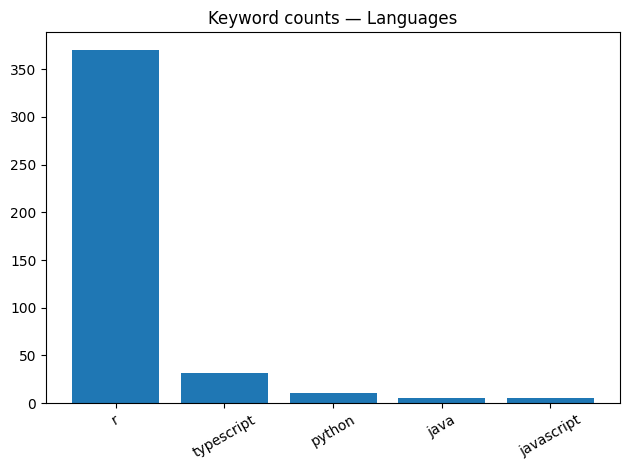

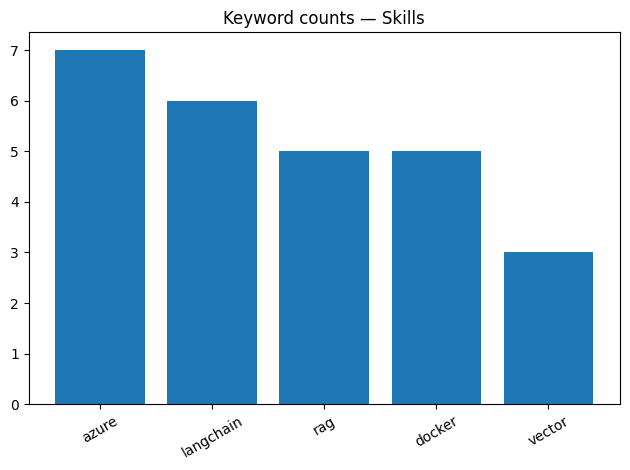

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path
Path("artifacts").mkdir(exist_ok=True)

if lang_counts:
    names, vals = zip(*lang_counts)
    plt.figure()
    plt.bar(names, vals)
    plt.title("Keyword counts — Languages")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig("artifacts/lang_counts.png", dpi=200)
    plt.show()

if skill_counts:
    names, vals = zip(*skill_counts)
    plt.figure()
    plt.bar(names, vals)
    plt.title("Keyword counts — Skills")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig("artifacts/skill_counts.png", dpi=200)
    plt.show()


In [ ]:
top_langs_seen  = [x[0] for x in lang_counts]
top_skills_seen = [x[0] for x in skill_counts]
notes = f"Sanity-check keywords show langs={top_langs_seen}, skills={top_skills_seen}."
result["notes"] = notes
with open("artifacts/result.json","w") as f:
    json.dump(result, f, indent=2)
print("Updated artifacts/result.json with notes.")


Updated artifacts/result.json with notes.


In [ ]:
import pandas as pd

pd.DataFrame(lang_counts,  columns=["language","count"]).to_csv("artifacts/lang_counts.csv", index=False)
pd.DataFrame(skill_counts, columns=["skill","count"]).to_csv("artifacts/skill_counts.csv", index=False)
print("Saved: artifacts/lang_counts.csv, artifacts/skill_counts.csv")


Saved: artifacts/lang_counts.csv, artifacts/skill_counts.csv


In [ ]:
from pptx import Presentation
from pptx.util import Inches, Pt

prs = Presentation()
slide = prs.slides.add_slide(prs.slide_layouts[5])

tx = slide.shapes.add_textbox(Inches(0.5), Inches(0.5), Inches(9), Inches(1))
tf = tx.text_frame; p = tf.paragraphs[0]
p.text = "Automated JD Analyzer — Summary"; p.font.size = Pt(28); p.font.bold = True

body = slide.shapes.add_textbox(Inches(0.5), Inches(1.4), Inches(9), Inches(5))
tfb = body.text_frame; tfb.clear()
def add_line(t, s):
    q = t.add_paragraph(); q.text = s; q.font.size = Pt(16)

tfb.text = f"Target role: {result.get('target_role','')}"
tfb.paragraphs[0].font.size = Pt(18)
add_line(tfb, "Top programming languages: " + ", ".join(result.get("top_programming_languages", [])))
add_line(tfb, "Top skills: " + ", ".join(result.get("top_skills", [])))
add_line(tfb, "Biggest skill gap: " + result.get("biggest_skill_gap", ""))
add_line(tfb, "Why JSON: Machine-readable, easy to parse & dashboard.")

out_pptx = "artifacts/JD_Analyzer_Summary.pptx"
prs.save(out_pptx)
out_pptx


'artifacts/JD_Analyzer_Summary.pptx'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')